In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

print("Libraries Loaded")

Libraries Loaded


In [2]:
#data loading
load_dotenv()
DATA_PATH_2025 = os.getenv("LOL_DATA_PATH_2025")
DATA_PATH_2026 = os.getenv("LOL_DATA_PATH_2026")


df_2025 = pd.read_csv(DATA_PATH_2025)
df_2026 = pd.read_csv(DATA_PATH_2026)
df = df = pd.concat([df_2025, df_2026], ignore_index=True)

lck = df[(df['position'] == 'team') & (df['league'] == 'LCK')]
print(lck.groupby(['year', 'split', 'teamname'])['gameid'].count().reset_index())


/var/folders/yl/g2yhdnld5bz781_vfpkgqnq80000gn/T/ipykernel_8292/3998373337.py:7: DtypeWarning: Columns (0: url) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025 = pd.read_csv(DATA_PATH_2025)


    year       split             teamname  gameid
0   2025         Cup            BNK FEARX      13
1   2025         Cup           DN SOOPers      15
2   2025         Cup                  DRX      21
3   2025         Cup            Dplus Kia      26
4   2025         Cup                Gen.G      29
5   2025         Cup         HANJIN BRION      14
6   2025         Cup  Hanwha Life Esports      33
7   2025         Cup           KT Rolster      16
8   2025         Cup    Nongshim RedForce      31
9   2025         Cup                   T1      20
10  2025  Rounds 1-2            BNK FEARX      46
11  2025  Rounds 1-2           DN SOOPers      43
12  2025  Rounds 1-2                  DRX      42
13  2025  Rounds 1-2            Dplus Kia      52
14  2025  Rounds 1-2                Gen.G      46
15  2025  Rounds 1-2         HANJIN BRION      47
16  2025  Rounds 1-2  Hanwha Life Esports      50
17  2025  Rounds 1-2           KT Rolster      57
18  2025  Rounds 1-2    Nongshim RedForce      48


/var/folders/yl/g2yhdnld5bz781_vfpkgqnq80000gn/T/ipykernel_8292/3998373337.py:8: DtypeWarning: Columns (0: url) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2026 = pd.read_csv(DATA_PATH_2026)


In [3]:
#data processing
lck['date'] = pd.to_datetime(lck['date'])
lck = lck.sort_values('date').reset_index(drop=True)

cols = ['gameid', 'date', 'patch', "side", 'teamname', 'result', 
        'golddiffat15', 'firstdragon', 'firstherald', 
        'firsttower']

lck = lck[cols]

print(lck.shape)
print(lck.head())

(1384, 10)
             gameid                date  patch  side      teamname  result  \
0  LOLTMNT03_183532 2025-01-15 08:09:30  15.01  Blue  HANJIN BRION       1   
1  LOLTMNT03_183532 2025-01-15 08:09:30  15.01   Red           DRX       0   
2  LOLTMNT03_183538 2025-01-15 09:03:08  15.01  Blue           DRX       1   
3  LOLTMNT03_183538 2025-01-15 09:03:08  15.01   Red  HANJIN BRION       0   
4  LOLTMNT03_183544 2025-01-15 09:54:37  15.01  Blue  HANJIN BRION       0   

   golddiffat15  firstdragon  firstherald  firsttower  
0        3067.0          1.0          1.0         1.0  
1       -3067.0          0.0          0.0         0.0  
2        1476.0          1.0          1.0         1.0  
3       -1476.0          0.0          0.0         0.0  
4        1993.0          0.0          1.0         0.0  


In [4]:
lck = lck.sort_values(['teamname', 'date']).reset_index(drop=True)

def add_rolling_features(df, window=5):
    df = df.copy()
    
    for team, group in df.groupby('teamname'):
        idx = group.index

        df.loc[idx, 'roll_winrate'] = (
            group['result'].shift(1).rolling(window, min_periods=1).mean()
        )

        df.loc[idx, 'roll_golddiff15'] = (
            group['golddiffat15'].shift(1).rolling(window, min_periods=1).mean()
        )
        
        df.loc[idx, 'roll_firstdragon'] = (
            group['firstdragon'].shift(1).rolling(window, min_periods=1).mean()
        )

        df.loc[idx, 'roll_firstherald'] = (
            group['firstherald'].shift(1).rolling(window, min_periods=1).mean()
        )

        df.loc[idx, 'roll_firsttower'] = (
            group['firsttower'].shift(1).rolling(window, min_periods=1).mean()
        )
        
        df.loc[idx, 'patch_winrate'] = (
            group.groupby('patch')['result']
            .transform(lambda x: x.shift(1).expanding().mean())
        )
    
    return df

lck_featured = add_rolling_features(lck, window=5)
print(lck_featured[['teamname', 'date', 'patch', 'result', 
           'roll_winrate', 'roll_golddiff15', 'patch_winrate']].head(10))
print(lck_featured.head(5))

    teamname                date  patch  result  roll_winrate  \
0  BNK FEARX 2025-01-16 08:09:06  15.01       0           NaN   
1  BNK FEARX 2025-01-16 09:04:00  15.01       1      0.000000   
2  BNK FEARX 2025-01-16 09:54:20  15.01       0      0.500000   
3  BNK FEARX 2025-01-19 08:34:13  15.01       0      0.333333   
4  BNK FEARX 2025-01-19 09:34:45  15.01       0      0.250000   
5  BNK FEARX 2025-01-22 08:04:43  15.01       0      0.200000   
6  BNK FEARX 2025-01-22 08:55:05  15.01       1      0.200000   
7  BNK FEARX 2025-01-22 09:48:21  15.01       0      0.200000   
8  BNK FEARX 2025-01-24 08:05:35  15.01       0      0.200000   
9  BNK FEARX 2025-01-24 08:59:16  15.01       1      0.200000   

   roll_golddiff15  patch_winrate  
0              NaN            NaN  
1          -3266.0       0.000000  
2           -274.5       0.500000  
3             85.0       0.333333  
4            137.0       0.250000  
5           -627.0       0.200000  
6             77.6       0.16666

In [5]:
print(lck_featured[lck_featured['gameid'] == 'LOLTMNT03_183532'][['gameid', 'teamname', 'side']])

               gameid      teamname  side
262  LOLTMNT03_183532           DRX   Red
673  LOLTMNT03_183532  HANJIN BRION  Blue


In [6]:
blue = lck_featured[lck_featured['side'] == 'Blue'].copy()
red = lck_featured[lck_featured['side'] == 'Red'].copy()

feature_cols = ['roll_winrate', 'roll_golddiff15', 'roll_firstdragon', 
                'roll_firstherald', 'roll_firsttower', 'patch_winrate']

blue = blue.rename(columns={col: f'blue_{col}' for col in feature_cols})
red = red.rename(columns={col: f'red_{col}' for col in feature_cols})

merged = pd.merge(
    blue[['gameid', 'date', 'patch', 'result'] + [f'blue_{col}' for col in feature_cols]],
    red[['gameid'] + [f'red_{col}' for col in feature_cols]],
    on='gameid'
)

for col in feature_cols:
    merged[f'diff_{col}'] = merged[f'blue_{col}'] - merged[f'red_{col}']

print(merged.shape)
print(merged[['gameid', 'date', 'result'] + [f'diff_{col}' for col in feature_cols]].head())

(692, 22)
             gameid                date  result  diff_roll_winrate  \
0  LOLTMNT03_184086 2025-01-16 08:09:06       0                NaN   
1  LOLTMNT03_183991 2025-01-16 09:04:00       1          -1.000000   
2  LOLTMNT03_187470 2025-01-19 08:34:13       0          -0.666667   
3  LOLTMNT03_187471 2025-01-19 09:34:45       0          -0.750000   
4  LOLTMNT03_188645 2025-01-22 08:55:05       1          -0.600000   

   diff_roll_golddiff15  diff_roll_firstdragon  diff_roll_firstherald  \
0                   NaN                    NaN                    NaN   
1               -6532.0              -1.000000              -1.000000   
2               -3603.0               0.000000              -0.666667   
3               -2224.0              -0.333333              -0.166667   
4                  64.2               0.000000              -0.400000   

   diff_roll_firsttower  diff_patch_winrate  
0                   NaN                 NaN  
1             -1.000000           -1.0

In [7]:
print(merged.isna().sum())
print(f"\ncol: {len(merged)}")
print(f"col with NaN: {merged.isna().any(axis=1).sum()}")


gameid                    0
date                      0
patch                     0
result                    0
blue_roll_winrate         6
blue_roll_golddiff15      6
blue_roll_firstdragon     6
blue_roll_firstherald     6
blue_roll_firsttower      6
blue_patch_winrate       79
red_roll_winrate          5
red_roll_golddiff15       5
red_roll_firstdragon      5
red_roll_firstherald      5
red_roll_firsttower       5
red_patch_winrate        77
diff_roll_winrate         6
diff_roll_golddiff15      6
diff_roll_firstdragon     6
diff_roll_firstherald     6
diff_roll_firsttower      6
diff_patch_winrate       89
dtype: int64

col: 692
col with NaN: 89


In [8]:
diff_cols = [f'diff_{col}' for col in feature_cols]

model_df = merged.copy()
model_df['diff_patch_winrate'] = model_df['diff_patch_winrate'].fillna(0)

model_df['blue_patch_winrate'] = model_df['blue_patch_winrate'].fillna(0.5)
model_df['red_patch_winrate'] = model_df['red_patch_winrate'].fillna(0.5)

model_df['diff_patch_winrate'] = model_df['blue_patch_winrate'] - model_df['red_patch_winrate']

model_df = model_df.dropna(subset=[c for c in diff_cols if c != 'diff_patch_winrate']).copy()
model_df = model_df.sort_values('date').reset_index(drop=True)

print(f"Entire mathces: {len(merged)} matches")
print(f"training data: {len(model_df)}th matches")
print(f"dropped matches: {len(merged) - len(model_df)} matches")
print(f"\nlef Na:")
print(model_df[diff_cols].isna().sum())

Entire mathces: 692 matches
training data: 686th matches
dropped matches: 6 matches

lef Na:
diff_roll_winrate        0
diff_roll_golddiff15     0
diff_roll_firstdragon    0
diff_roll_firstherald    0
diff_roll_firsttower     0
diff_patch_winrate       0
dtype: int64


In [9]:
import warnings
warnings.filterwarnings('ignore')

X = model_df[diff_cols]
y = model_df['result']

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Logistic Regression': LogisticRegression(),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    accs, aucs = [], []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)
        
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
        proba = model.predict_proba(X_test_sc)[:, 1]
        
        accs.append(accuracy_score(y_test, preds))
        aucs.append(roc_auc_score(y_test, proba))
    
    print(f"{name}")
    print(f"  Accuracy: {np.mean(accs):.3f} (+/- {np.std(accs):.3f})")
    print(f"  ROC-AUC:  {np.mean(aucs):.3f} (+/- {np.std(aucs):.3f})")

Logistic Regression
  Accuracy: 0.567 (+/- 0.037)
  ROC-AUC:  0.630 (+/- 0.072)
Gradient Boosting
  Accuracy: 0.537 (+/- 0.014)
  ROC-AUC:  0.573 (+/- 0.021)


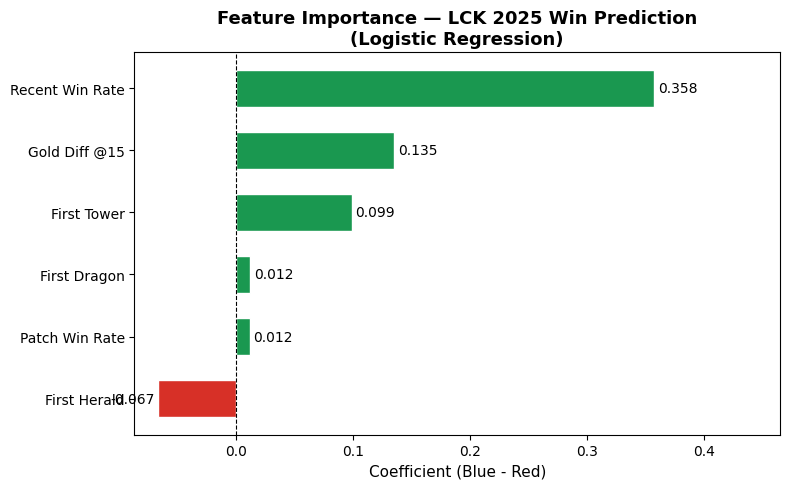

saved: feature_importance.png


In [10]:
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

lr_final = LogisticRegression()
lr_final.fit(X_scaled, y)

coef = pd.Series(lr_final.coef_[0], index=diff_cols).sort_values()

label_map = {
    'diff_roll_winrate':     'Recent Win Rate',
    'diff_roll_golddiff15':  'Gold Diff @15',
    'diff_roll_firstdragon': 'First Dragon',
    'diff_roll_firstherald': 'First Herald',
    'diff_roll_firsttower':  'First Tower',
    'diff_patch_winrate':    'Patch Win Rate'
}
coef.index = [label_map[i] for i in coef.index]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d73027' if v < 0 else '#1a9850' for v in coef.values]
bars = ax.barh(coef.index, coef.values, color=colors, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (Blue - Red)', fontsize=11)
ax.set_title('Feature Importance — LCK 2025 Win Prediction\n(Logistic Regression)', fontsize=13, fontweight='bold')
ax.set_xlim(min(coef.values) * 1.3, max(coef.values) * 1.3)

for bar, val in zip(bars, coef.values):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: feature_importance.png")

In [11]:
import joblib

joblib.dump(lr_final, 'lck_model.pkl')
joblib.dump(scaler_final, 'lck_scaler.pkl')

def get_team_features(team_name, df=lck_featured):
    team_df = df[df['teamname'] == team_name].sort_values('date')
    latest = team_df.iloc[-1]
    return {
        'roll_winrate':     latest['roll_winrate'],
        'roll_golddiff15':  latest['roll_golddiff15'],
        'roll_firstdragon': latest['roll_firstdragon'],
        'roll_firstherald': latest['roll_firstherald'],
        'roll_firsttower':  latest['roll_firsttower'],
        'patch_winrate':    latest['patch_winrate'] if pd.notna(latest['patch_winrate']) else 0.5
    }

def predict_match(blue_team, red_team):
    blue = get_team_features(blue_team)
    red = get_team_features(red_team)
    
    diff = {f'diff_{k}': blue[k] - red[k] for k in blue.keys()}
    
    X_pred = pd.DataFrame([diff])[diff_cols]
    X_pred_sc = scaler_final.transform(X_pred)
    
    proba = lr_final.predict_proba(X_pred_sc)[0]
    
    print(f"\n{blue_team} (Blue) vs {red_team} (Red)")
    print(f"  {blue_team} winrate: {proba[1]:.1%}")
    print(f"  {red_team} winrate:  {proba[0]:.1%}")
    print(f"  predicted winner: {blue_team if proba[1] > 0.5 else red_team}")
    
    return proba

predict_match('T1', 'Hanwha Life Esports')
predict_match('KT Rolster', 'Dplus Kia')


T1 (Blue) vs Hanwha Life Esports (Red)
  T1 winrate: 48.5%
  Hanwha Life Esports winrate:  51.5%
  predicted winner: Hanwha Life Esports

KT Rolster (Blue) vs Dplus Kia (Red)
  KT Rolster winrate: 68.4%
  Dplus Kia winrate:  31.6%
  predicted winner: KT Rolster


array([0.31610085, 0.68389915])

In [12]:
os.makedirs('../backend/models', exist_ok=True)
os.makedirs('../backend/data', exist_ok=True)

joblib.dump(lr_final, '../backend/models/lck_model.pkl')
joblib.dump(scaler_final, '../backend/models/lck_scaler.pkl')
joblib.dump(lck_featured, '../backend/data/lck_featured.pkl')

print("saved pkl")

saved pkl
